# LookBench Data Exploration

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SerendipityOneInc/look-bench/blob/main/notebooks/00_data_exploration.ipynb)

This notebook demonstrates how to download, explore, and analyze the **LookBench** dataset.

📄 **Paper**: [LookBench: A Live and Holistic Open Benchmark for Fashion Image Retrieval](https://arxiv.org/abs/2601.14706)

🏠 **Project Page**: [https://serendipityoneinc.github.io/look-bench-page/](https://serendipityoneinc.github.io/look-bench-page/)

🤗 **Dataset**: [https://huggingface.co/datasets/srpone/look-bench](https://huggingface.co/datasets/srpone/look-bench)

## Setup and Installation

First, let's install the required packages.

In [1]:
# Install look-bench (includes datasets)
%pip install -q look-bench

# Install matplotlib for visualization
%pip install -q matplotlib

print("✅ Installation complete!")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
✅ Installation complete!


## 1. Download LookBench Dataset

The LookBench dataset has 5 configs that need to be loaded separately:
- **real_studio_flat**: Real studio flat-lay photos (Easy)
- **aigen_studio**: AI-generated lifestyle images (Medium)
- **real_streetlook**: Real street outfit photos (Hard)
- **aigen_streetlook**: AI-generated street outfits (Hard)
- **noise**: Noise/distractor images

In [2]:
from datasets import load_dataset
from collections import Counter
import matplotlib.pyplot as plt

# Available configs
configs = ['aigen_streetlook', 'aigen_studio', 'real_streetlook', 'real_studio_flat', 'noise']

print("Downloading LookBench dataset from Hugging Face...")
print("This may take a few minutes on first run...\n")

# Load all configs
dataset = {}
for config_name in configs:
    print(f"  Loading {config_name}...")
    dataset[config_name] = load_dataset("srpone/look-bench", config_name)

print("\n✅ Dataset downloaded successfully!")

c:\Users\i_am_fuch\Desktop\look-bench\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


This may take a few minutes on first run...

  Loading aigen_streetlook...


c:\Users\i_am_fuch\Desktop\look-bench\venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\i_am_fuch\.cache\huggingface\hub\datasets--srpone--look-bench. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating gallery split: 100%|██████████| 571/571 [00:00<00:00, 19266.39 examples/s]


  Loading aigen_studio...


Generating gallery split: 100%|██████████| 979/979 [00:00<00:00, 34202.57 examples/s]


  Loading real_streetlook...


Generating gallery split: 100%|██████████| 3278/3278 [00:00<00:00, 26982.60 examples/s]


  Loading real_studio_flat...
  Loading noise...


Generating gallery split: 100%|██████████| 58275/58275 [00:02<00:00, 20508.79 examples/s]



✅ Dataset downloaded successfully!


## 2. Explore Dataset Structure

In [3]:
print("="*70)
print(" Dataset Structure")
print("="*70)

print(f"\nAvailable configs: {list(dataset.keys())}")
print(f"Total configs: {len(dataset.keys())}\n")

for config_name in dataset.keys():
    print(f"📁 {config_name}:")
    subset_data = dataset[config_name]
    for split_name in subset_data.keys():
        num_samples = len(subset_data[split_name])
        print(f"   ├─ {split_name}: {num_samples:,} samples")
    print()

 Dataset Structure

Available configs: ['aigen_streetlook', 'aigen_studio', 'real_streetlook', 'real_studio_flat', 'noise']
Total configs: 5

📁 aigen_streetlook:
   ├─ query: 160 samples
   ├─ gallery: 571 samples

📁 aigen_studio:
   ├─ query: 193 samples
   ├─ gallery: 979 samples

📁 real_streetlook:
   ├─ query: 981 samples
   ├─ gallery: 3,278 samples

📁 real_studio_flat:
   ├─ query: 1,011 samples
   ├─ gallery: 3,951 samples

📁 noise:
   ├─ gallery: 58,275 samples



## 3. Dataset Summary

In [4]:
total_images = 0
total_categories = set()

for config_name in dataset.keys():
    subset_data = dataset[config_name]
    for split_name in subset_data.keys():
        split_data = subset_data[split_name]
        total_images += len(split_data)
        
        # Collect unique categories
        for sample in split_data:
            if 'category' in sample:
                total_categories.add(sample['category'])

print("="*70)
print(" Dataset Summary Report")
print("="*70)
print(f"\n📈 Overall Statistics:")
print(f"  • Total configs: {len(dataset.keys())}")
print(f"  • Total images: {total_images:,}")
print(f"  • Unique categories: {len(total_categories)}")
print(f"\n📋 Available configs:")
for config in sorted(dataset.keys()):
    print(f"  • {config}")

 Dataset Summary Report

📈 Overall Statistics:
  • Total configs: 5
  • Total images: 69,399
  • Unique categories: 104

📋 Available configs:
  • aigen_streetlook
  • aigen_studio
  • noise
  • real_streetlook
  • real_studio_flat


## 4. Compare Configs

In [5]:
print("="*70)
print(" Cross-Config Comparison")
print("="*70)

print("\n📊 Config Comparison:")
print(f"{'Config':<25} {'Query':<10} {'Gallery':<10} {'Total':<10}")
print("-" * 60)

total_queries = 0
total_gallery = 0

for config_name in sorted(dataset.keys()):
    subset_data = dataset[config_name]
    num_queries = len(subset_data['query']) if 'query' in subset_data else 0
    num_gallery = len(subset_data['gallery']) if 'gallery' in subset_data else 0
    total = num_queries + num_gallery
    
    print(f"{config_name:<25} {num_queries:<10,} {num_gallery:<10,} {total:<10,}")
    total_queries += num_queries
    total_gallery += num_gallery

print("-" * 60)
print(f"{'TOTAL':<25} {total_queries:<10,} {total_gallery:<10,} {total_queries + total_gallery:<10,}")

 Cross-Config Comparison

📊 Config Comparison:
Config                    Query      Gallery    Total     
------------------------------------------------------------
aigen_streetlook          160        571        731       
aigen_studio              193        979        1,172     
noise                     0          58,275     58,275    
real_streetlook           981        3,278      4,259     
real_studio_flat          1,011      3,951      4,962     
------------------------------------------------------------
TOTAL                     2,345      67,054     69,399    


## 5. Analyze Individual Config Statistics

In [6]:
def analyze_config_statistics(dataset, config_name):
    """Analyze and print statistics for a specific config"""
    print("\n" + "="*70)
    print(f" Statistics for '{config_name}'")
    print("="*70)
    
    if config_name not in dataset:
        print(f"Config '{config_name}' not found!")
        return
    
    subset_data = dataset[config_name]
    
    # Query statistics
    if 'query' in subset_data:
        query_data = subset_data['query']
        print(f"\n📊 Query Split ({len(query_data):,} samples):")
        
        # Category distribution
        categories = [sample['category'] for sample in query_data]
        category_counts = Counter(categories)
        print(f"\n  Categories ({len(category_counts)} unique):")
        for cat, count in category_counts.most_common(10):
            print(f"    • {cat}: {count}")
        
        # Task distribution
        if 'task' in query_data[0]:
            tasks = [sample['task'] for sample in query_data]
            task_counts = Counter(tasks)
            print(f"\n  Tasks:")
            for task, count in task_counts.items():
                print(f"    • {task}: {count} ({count/len(query_data)*100:.1f}%)")
        
        # Difficulty distribution
        if 'difficulty' in query_data[0]:
            difficulties = [sample['difficulty'] for sample in query_data]
            diff_counts = Counter(difficulties)
            print(f"\n  Difficulty levels:")
            for diff, count in diff_counts.items():
                print(f"    • {diff}: {count} ({count/len(query_data)*100:.1f}%)")
        
        # Attribute statistics
        if 'main_attribute' in query_data[0]:
            main_attrs = [sample['main_attribute'] for sample in query_data]
            attr_counts = Counter(main_attrs)
            print(f"\n  Main attributes ({len(attr_counts)} unique):")
            for attr, count in attr_counts.most_common(5):
                print(f"    • {attr}: {count}")
    
    # Gallery statistics
    if 'gallery' in subset_data:
        gallery_data = subset_data['gallery']
        print(f"\n📚 Gallery Split ({len(gallery_data):,} samples):")
        
        categories = [sample['category'] for sample in gallery_data]
        category_counts = Counter(categories)
        print(f"\n  Categories ({len(category_counts)} unique):")
        for cat, count in category_counts.most_common(10):
            print(f"    • {cat}: {count}")

# Analyze main configs (skip noise for detailed analysis)
main_configs = ['real_studio_flat', 'aigen_studio', 'real_streetlook', 'aigen_streetlook']
for config_name in main_configs:
    if config_name in dataset:
        analyze_config_statistics(dataset, config_name)


 Statistics for 'real_studio_flat'

📊 Query Split (1,011 samples):

  Categories (44 unique):
    • blouse: 82
    • dress: 66
    • t-shirt: 61
    • pants: 59
    • sweatshirt: 58
    • jacket: 55
    • sweater: 53
    • coat: 52
    • skirt: 50
    • shirt: 45

  Tasks:
    • RealStudioFlat: 1011 (100.0%)

  Difficulty levels:
    • easy: 1011 (100.0%)

  Main attributes (134 unique):
    • plain: 65
    • casual: 57
    • cotton: 34
    • elegant: 32
    • long_sleeve: 28

📚 Gallery Split (3,951 samples):

  Categories (59 unique):
    • sweater: 349
    • jacket: 259
    • sweatshirt: 251
    • dress: 237
    • pants: 210
    • blouse: 205
    • t-shirt: 205
    • coat: 205
    • skirt: 190
    • hat: 183

 Statistics for 'aigen_studio'

📊 Query Split (193 samples):

  Categories (26 unique):
    • dress: 18
    • shirt: 18
    • blouse: 14
    • coat: 14
    • skirt: 13
    • t-shirt: 12
    • sweater: 11
    • jacket: 10
    • pants: 10
    • cardigan: 9

  Tasks:
    • AIGen-S

## 6. Display Sample Images

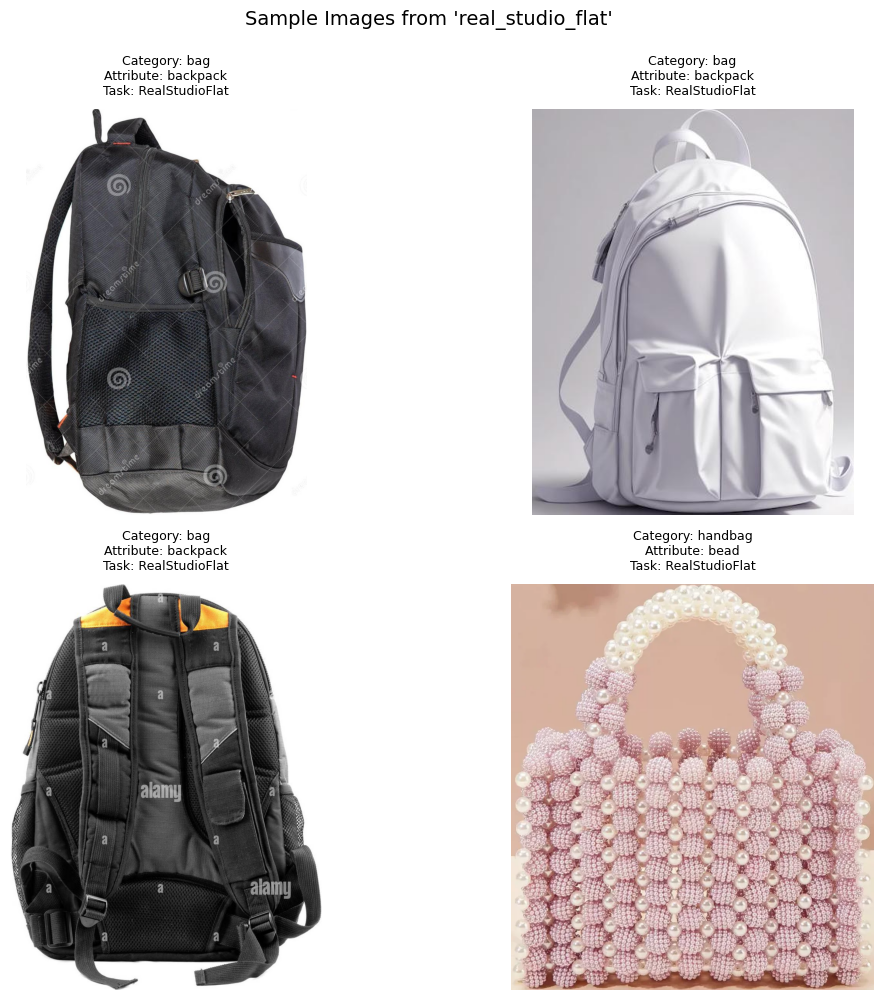

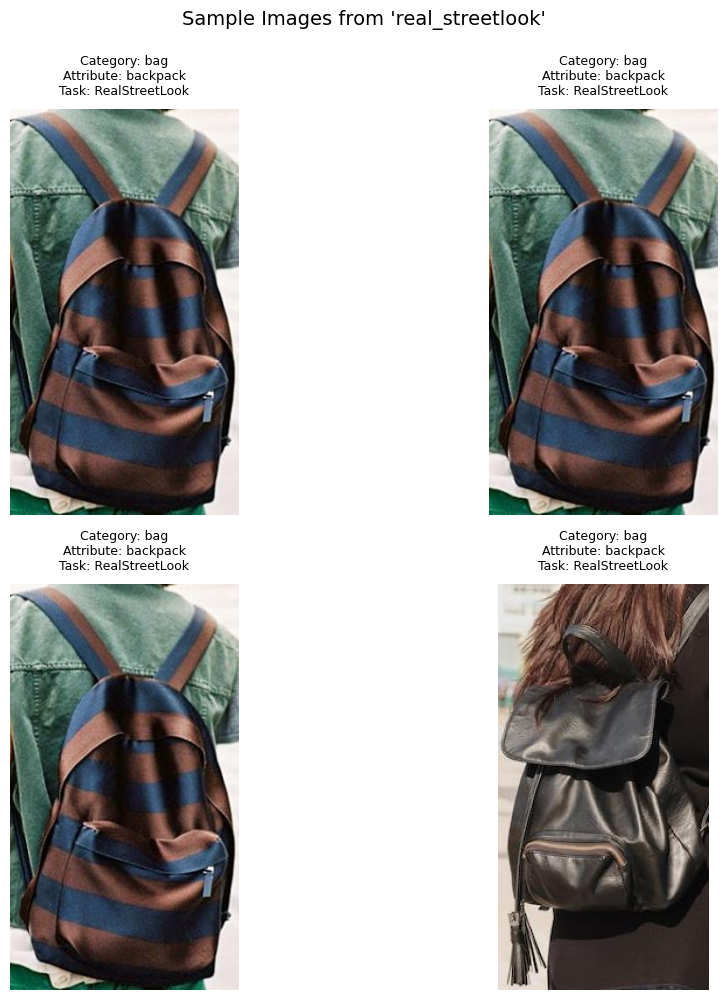

In [7]:
def display_sample_images(dataset, config_name, num_samples=4):
    """Display sample images from the dataset"""
    if config_name not in dataset:
        print(f"Config '{config_name}' not found!")
        return
    
    subset_data = dataset[config_name]
    if 'query' not in subset_data:
        print(f"Query split not found in '{config_name}'!")
        return
    
    query_data = subset_data['query']
    num_samples = min(num_samples, len(query_data))
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    for idx in range(num_samples):
        sample = query_data[idx]
        ax = axes[idx]
        
        # Display image
        ax.imshow(sample['image'])
        ax.axis('off')
        
        # Create title with metadata
        title = f"Category: {sample['category']}\n"
        if 'main_attribute' in sample:
            title += f"Attribute: {sample['main_attribute']}\n"
        if 'task' in sample:
            title += f"Task: {sample['task']}"
        
        ax.set_title(title, fontsize=9, pad=10)
    
    plt.suptitle(f"Sample Images from '{config_name}'", fontsize=14, y=0.995)
    plt.tight_layout()
    plt.show()

# Display samples from main configs
for config_name in ['real_studio_flat', 'real_streetlook']:
    if config_name in dataset:
        display_sample_images(dataset, config_name, num_samples=4)

## Summary

✅ Dataset exploration completed successfully!

📚 **Next Steps:**
1. Review the statistics above
2. Run `01_quickstart.ipynb` to test model inference
3. Run `02_model_evaluation.ipynb` for full benchmark evaluation

💡 **Resources:**
- 📄 Paper: https://arxiv.org/abs/2601.14706
- 🤗 Dataset: https://huggingface.co/datasets/srpone/look-bench
- 🏠 Project Page: https://serendipityoneinc.github.io/look-bench-page/
- 💻 GitHub: https://github.com/SerendipityOneInc/look-bench